In [2]:
# XGBoost algorithm

import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# loading dfs'
train_df = pd.read_csv(r"Y:\code\regression-pipeline\data\processed\fe_train.csv")
val_df = pd.read_csv(r"Y:\code\regression-pipeline\data\processed\fe_val.csv")

target = "price"

X_train = train_df.drop(columns=[target])
Y_train = train_df[target]

X_val = val_df.drop(columns=[target])
Y_val = val_df[target]

# Training a simple XGBoost Regressor
xgb_model = XGBRegressor(
    n_estimators = 500,
    learning_rate = 0.05,
    max_depth = 10,
    subsample = 0.8,
    cosample_bytree = 0.8,
    random_state = 42,
    n_jobs = 1
)

# Training the model
xgb_model.fit(X_train, Y_train)

# evaluating the model
Y_pred = xgb_model.predict(X_val)

print("XGBoost Metrics:")
print(f"MAE {mean_absolute_error(Y_val, Y_pred)}")
print(f"RMSE {np.sqrt(mean_squared_error(Y_val, Y_pred))}")
print(f"R² {r2_score(Y_val, Y_pred)}")

y:\code\regression-pipeline\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:53:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "cosample_bytree" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Metrics:
MAE 30948.101219467215
RMSE 74422.42640280443
R² 0.957197643322838


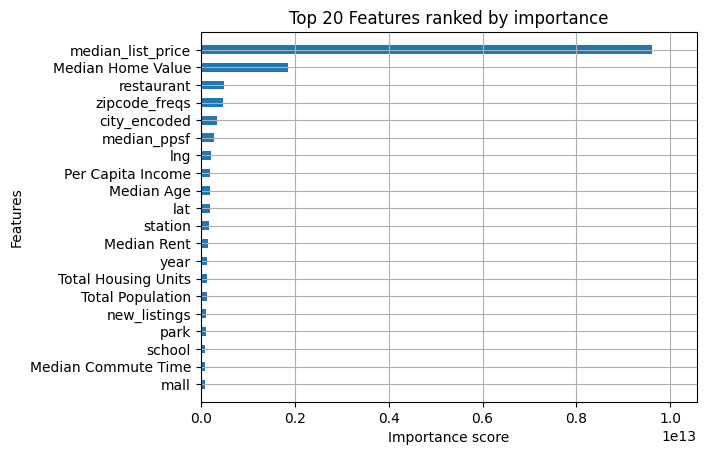

In [3]:
# visualizing the importance of features
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(
    xgb_model,
    importance_type = "gain",
    max_num_features = 20,
    height = 0.5,
    show_values = 20
)
plt.title("Top 20 Features ranked by importance")
plt.ylabel("Features")
plt.show()